In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf


DATA_PATH = Path("..") / "DS0001" / "38304-0001-Data.tsv"
df = pd.read_csv(DATA_PATH, sep="\t")

print(f"Loaded {len(df):,} rows")
print(age.describe())

Loaded 1,495 rows
count    1495.000000
mean       50.046154
std        13.409567
min        18.000000
25%        41.000000
50%        54.000000
75%        61.000000
max        86.000000
Name: AGE, dtype: float64


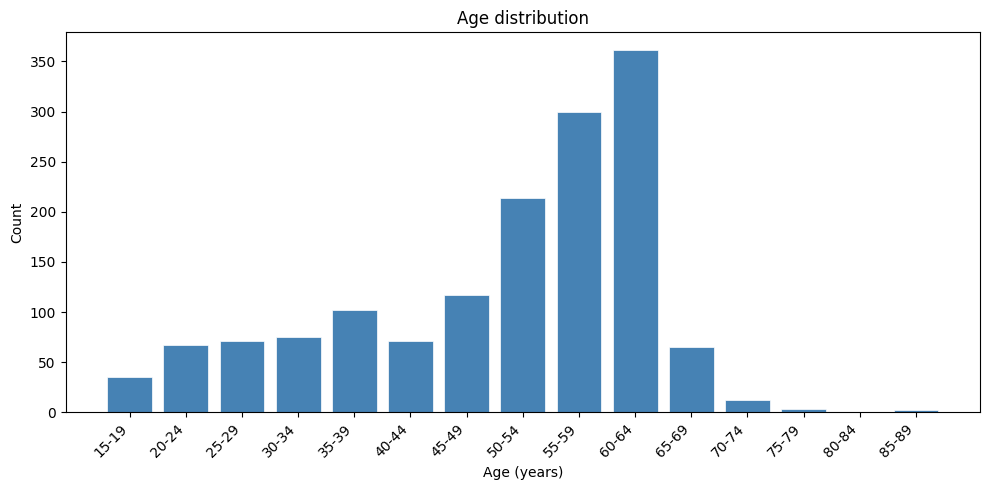

In [11]:
# Age distribution as a bar chart (5-year bins)
bin_edges = range(int(age.min() // 5 * 5), int(age.max() // 5 * 5) + 10, 5)
labels = [f"{lo}-{lo + 4}" for lo in bin_edges[:-1]]
binned = pd.cut(age, bins=list(bin_edges), right=False, labels=labels)
counts = binned.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Count")
ax.set_title("Age distribution")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plt.show()

In [ ]:
# --- Steps 1–4: Positive well-being index (higher = better well-being) ---
# Negative-oriented raw items: reverse-code so higher = better.
# Scales from data: WHO26, SBQ_1, MISSSF_1, LONELINESS_*; positives: WELLNESS_1, WHO19, WELLNESS_25.

def reverse_1_k(x: pd.Series, k: int) -> pd.Series:
    """Map 1..k -> k..1 (missing preserved)."""
    v = pd.to_numeric(x, errors="coerce")
    out = (k + 1) - v
    return out.where(v.notna() & v.between(1, k, inclusive="both"))


# Step 1: pull items
neg_raw = pd.DataFrame(
    {
        "WHO26_rev": reverse_1_k(df["WHO26"], 5),
        "SBQ_1_rev": reverse_1_k(df["SBQ_1"], 6),
        "MISSSF_1_rev": reverse_1_k(df["MISSSF_1"], 10),
        "LONELINESS_1_rev": reverse_1_k(df["LONELINESS_1"], 3),
        "LONELINESS_2_rev": reverse_1_k(df["LONELINESS_2"], 3),
        "LONELINESS_3_rev": reverse_1_k(df["LONELINESS_3"], 3),
    }
)
pos_raw = pd.DataFrame(
    {
        "WELLNESS_1": pd.to_numeric(df["WELLNESS_1"], errors="coerce"),
        "WHO19": pd.to_numeric(df["WHO19"], errors="coerce"),
        "WELLNESS_25": pd.to_numeric(df["WELLNESS_25"], errors="coerce"),
    }
)

# Step 2–3: z-score each oriented item (sample SD); combine only complete rows for the index
oriented = pd.concat([neg_raw, pos_raw], axis=1)


def zscore(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    mu, sd = s.mean(), s.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return s * np.nan
    return (s - mu) / sd


z_items = oriented.apply(zscore, axis=0)
# Step 4: mean of z-scores = composite (equal weight); require all 9 items (no partial means)
df["wellbeing_index_z"] = z_items.mean(axis=1, skipna=False)
df = df.copy()  # avoid fragmented frame after many column inserts
index_item_cols = list(z_items.columns)

print("Oriented items (after reverse-coding negatives):")
print(oriented.describe().T.round(3))
print("\nComposite (higher = better well-being), non-missing n:", df["wellbeing_index_z"].notna().sum())
print(df["wellbeing_index_z"].describe().round(4))



Oriented items (after reverse-coding negatives):
                   count   mean    std  min  25%  50%  75%   max
WHO26_rev         1495.0  3.728  0.987  1.0  3.0  4.0  4.0   5.0
SBQ_1_rev         1483.0  5.260  1.174  1.0  5.0  6.0  6.0   6.0
MISSSF_1_rev      1495.0  5.906  3.036  1.0  3.0  5.0  8.0  10.0
LONELINESS_1_rev  1495.0  2.386  0.701  1.0  2.0  3.0  3.0   3.0
LONELINESS_2_rev  1495.0  2.380  0.702  1.0  2.0  3.0  3.0   3.0
LONELINESS_3_rev  1495.0  2.348  0.732  1.0  2.0  3.0  3.0   3.0
WELLNESS_1        1495.0  3.723  1.042  1.0  3.0  4.0  4.0   5.0
WHO19             1495.0  3.766  1.050  1.0  3.0  4.0  5.0   5.0
WELLNESS_25       1495.0  3.765  0.989  1.0  3.0  4.0  4.0   5.0

Composite (higher = better well-being), non-missing n: 1483
count    1483.0000
mean        0.0006
std         0.6414
min        -2.2079
25%        -0.4015
50%         0.1016
75%         0.5063
max         1.0634
Name: wellbeing_index_z, dtype: float64


/var/folders/zl/vrkthn715j97ns3mht1gpfm80000gn/T/ipykernel_2882/3900917151.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["wellbeing_index_z"] = z_items.mean(axis=1, skipna=False)


In [4]:
# --- Step 5: Cronbach's alpha (on z-scored index items; standardized alpha) ---


def cronbach_alpha(items: pd.DataFrame) -> float:
    items = items.dropna(how="any")
    k = items.shape[1]
    if k < 2 or len(items) < 2:
        return float("nan")
    item_vars = items.var(axis=0, ddof=1)
    total = items.sum(axis=1)
    total_var = total.var(ddof=1)
    if total_var == 0 or np.isnan(total_var):
        return float("nan")
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)


alpha = cronbach_alpha(z_items)
print(f"Cronbach's alpha (standardized items, k={z_items.shape[1]}): {alpha:.3f}")
print("(Rule of thumb: ≥ 0.70 suggests acceptable internal consistency.)")



Cronbach's alpha (standardized items, k=9): 0.821
(Rule of thumb: ≥ 0.70 suggests acceptable internal consistency.)


In [ ]:
# --- Step 6: Regression predictors ---

survey_dt = pd.to_datetime(df["STARTDATE"], errors="coerce", format="mixed")
survey_year = survey_dt.dt.year
df["time_since_service_years"] = survey_year - pd.to_numeric(df["RETIRED"], errors="coerce")
df["CES_TOTAL"] = pd.to_numeric(df["CES_TOTAL"], errors="coerce")
df["RACE"] = pd.to_numeric(df["RACE"], errors="coerce")
df["INCOME"] = pd.to_numeric(df["INCOME"], errors="coerce")
df["AGE"] = pd.to_numeric(df["AGE"], errors="coerce")

reg_cols = [
    "wellbeing_index_z",
    "CES_TOTAL",
    "RACE", 
    "INCOME",
    "time_since_service_years",
    "AGE",
]
reg_df = df.dropna(subset=reg_cols).copy()
print(f"Regression complete-case n: {len(reg_df):,}")

# Example: combat × race on well-being (HC1 robust SEs)
fit = smf.ols(
    "wellbeing_index_z ~ CES_TOTAL * C(RACE) + INCOME + time_since_service_years + AGE",
    data=reg_df,
).fit(cov_type="HC1")
print(fit.summary())



Regression complete-case n: 1,483
                            OLS Regression Results                            
Dep. Variable:      wellbeing_index_z   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     11.42
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           2.43e-25
Time:                        15:16:09   Log-Likelihood:                -1374.8
No. Observations:                1483   AIC:                             2780.
Df Residuals:                    1468   BIC:                             2859.
Df Model:                          14                                         
Covariance Type:                  HC1                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

Younger ppl

In [ ]:
# --- Step 6: Regression predictors ---

survey_dt = pd.to_datetime(df["STARTDATE"], errors="coerce", format="mixed")
survey_year = survey_dt.dt.year
df["time_since_service_years"] = survey_year - pd.to_numeric(df["RETIRED"], errors="coerce")
df["CES_TOTAL"] = pd.to_numeric(df["CES_TOTAL"], errors="coerce")
df["RACE"] = pd.to_numeric(df["RACE"], errors="coerce")
df["INCOME"] = pd.to_numeric(df["INCOME"], errors="coerce")
df["AGE"] = pd.to_numeric(df["AGE"], errors="coerce")
df["AGE"] = pd.to_numeric(df["AGE"], errors="coerce")
df = df[df["AGE"] < 50].copy()
reg_cols = [
    "wellbeing_index_z",
    "CES_TOTAL",
    "RACE", 
    "INCOME",
    "time_since_service_years",
    "AGE",
]
reg_df = df.dropna(subset=reg_cols).copy()
print(f"Regression complete-case n: {len(reg_df):,}")

# Example: combat × race on well-being (HC1 robust SEs)
fit = smf.ols(
    "wellbeing_index_z ~ CES_TOTAL * C(RACE) + INCOME + time_since_service_years + AGE",
    data=reg_df,
).fit(cov_type="HC1")
print(fit.summary())



Regression complete-case n: 530
                            OLS Regression Results                            
Dep. Variable:      wellbeing_index_z   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     2.120
Date:                Fri, 24 Apr 2026   Prob (F-statistic):            0.00986
Time:                        15:16:09   Log-Likelihood:                -494.92
No. Observations:                 530   AIC:                             1020.
Df Residuals:                     515   BIC:                             1084.
Df Model:                          14                                         
Covariance Type:                  HC1                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------

In [7]:
# --- Nested model comparison: Age vs. multicollinearity with time_since_service_years ---
# Uses `reg_df` from the cells above (re-run those first so the sample matches your last regression).

formula_a = "wellbeing_index_z ~ CES_TOTAL * C(RACE) + INCOME + time_since_service_years + AGE"
formula_b = "wellbeing_index_z ~ CES_TOTAL * C(RACE) + INCOME + AGE"

fit_a = smf.ols(formula_a, data=reg_df).fit(cov_type="HC1")
fit_b = smf.ols(formula_b, data=reg_df).fit(cov_type="HC1")

print("Model A (full):", formula_a)
print("Model B (drop time_since_service_years):", formula_b)
print(f"N = {len(reg_df):,}\n")

print("--- Age coefficient ---")
print("Model A  AGE coef:", fit_a.params["AGE"], "  P-value:", fit_a.pvalues["AGE"])
print("Model B  AGE coef:", fit_b.params["AGE"], "  P-value:", fit_b.pvalues["AGE"])

print("\n--- Fit (nested: B inside A) ---")
print(f"Model A  R-squared: {fit_a.rsquared:.4f}  Adj. R-squared: {fit_a.rsquared_adj:.4f}  AIC: {fit_a.aic:.1f}")
print(f"Model B  R-squared: {fit_b.rsquared:.4f}  Adj. R-squared: {fit_b.rsquared_adj:.4f}  AIC: {fit_b.aic:.1f}")

# Likelihood-ratio test (note: invalid under heteroskedasticity; statsmodels warns if using HC1)
lr_stat, p_lr, df_diff = fit_a.compare_lr_test(fit_b)
print(f"\nLR test (A vs B, H0: time_since coef == 0): chi2({df_diff:.0f}) = {lr_stat:.4f}, p = {p_lr:.4f}")
print("(Large p → dropping time_since is not rejected; small p → full model improves fit.)")

# Classical nested F-test (homoskedastic OLS) — valid comparison for nested models here
from scipy.stats import f as f_distribution

fit_a_ml = smf.ols(formula_a, data=reg_df).fit()
fit_b_ml = smf.ols(formula_b, data=reg_df).fit()
q = int(round(fit_a_ml.df_model - fit_b_ml.df_model))
F_stat = ((fit_b_ml.ssr - fit_a_ml.ssr) / q) / (fit_a_ml.ssr / fit_a_ml.df_resid)
p_f = float(f_distribution.sf(F_stat, q, fit_a_ml.df_resid))
print(
    f"\nNested F-test (classical OLS): F({q},{fit_a_ml.df_resid:.0f}) = {F_stat:.4f}, p = {p_f:.4f}"
)



Model A (full): wellbeing_index_z ~ CES_TOTAL * C(RACE) + INCOME + time_since_service_years + AGE
Model B (drop time_since_service_years): wellbeing_index_z ~ CES_TOTAL * C(RACE) + INCOME + AGE
N = 530

--- Age coefficient ---
Model A  AGE coef: 0.003230049901758255   P-value: 0.3937087356535881
Model B  AGE coef: 0.004085847280518693   P-value: 0.20585193255551648

--- Fit (nested: B inside A) ---
Model A  R-squared: 0.0451  Adj. R-squared: 0.0191  AIC: 1019.8
Model B  R-squared: 0.0447  Adj. R-squared: 0.0207  AIC: 1018.0

LR test (A vs B, H0: time_since coef == 0): chi2(1) = 0.1836, p = 0.6683
(Large p → dropping time_since is not rejected; small p → full model improves fit.)

Nested F-test (classical OLS): F(1,515) = 0.1785, p = 0.6729


/Users/katherineharvey/anaconda3/envs/test/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:2376: InvalidTestWarning: Likelihood Ratio test is likely invalid with robust covariance, proceeding anyway
  warnings.warn('Likelihood Ratio test is likely invalid with ' +


In [8]:
# --- Combat exposure × Age (interaction) ---
# Does the association between CES_TOTAL and well-being change with age?
# Uses current `df` from cells above (re-run those first; any filter such as AGE < 50 still applies).

_int_cols = ["wellbeing_index_z", "CES_TOTAL", "AGE", "RACE", "INCOME"]
_reg_ces_age = df.dropna(subset=_int_cols).copy()
print(f"Complete-case n: {len(_reg_ces_age):,}")

fit_ces_age = smf.ols(
    "wellbeing_index_z ~ CES_TOTAL * AGE + C(RACE) + INCOME",
    data=_reg_ces_age,
).fit(cov_type="HC1")
print(fit_ces_age.summary())
print(
    "\nInterpretation: focus on CES_TOTAL, AGE, and CES_TOTAL:AGE. "
    "A negative interaction, for example, would mean the CES–well-being slope becomes more negative at higher ages (associational)."
)



Complete-case n: 530
                            OLS Regression Results                            
Dep. Variable:      wellbeing_index_z   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     2.976
Date:                Fri, 24 Apr 2026   Prob (F-statistic):            0.00183
Time:                        15:16:09   Log-Likelihood:                -494.05
No. Observations:                 530   AIC:                             1008.
Df Residuals:                     520   BIC:                             1051.
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.5908 